# Aprendizaje Estadístico y Data Mining

## Práctica 4: Desguace Beni

### Objetivo
Un desguace de Madrid quiere automatizar la entrada de coches para ser más óptimo a la hora de despiezarlos y separar las distintas partes de los coches que reciben. Para ello han decidido crear un clasificador basado en las diferentes características de los coches y la probabilidad que pertenezca a una clase de coche u otra.

Para ello usaremos el dataset **“vehicles.csv”** que se encuentra en Canvas. Elige el clasificador que más se adapte de entre los vistos en clase y usa *scikit-learn* junto con las librerías que necesites para resolver las siguientes cuestiones. Muestra todos los resultados del algoritmo paso a paso.

* [Link al dataset.](https://ufv-es.instructure.com/courses/42756/files/6048677/download?download_frd=1)

**Enunciado:**  Realiza todo el preprocesamiento necesario para poder entrenar el clasificador. (Ojo: las temperaturas están en grados Celsius.) 

**Solución**

Los árboles de decisión son un tipo de clasificador supervisado que se utiliza para predecir la clase de una instancia a partir de un conjunto de atributos. El modelo se representa con una estructura en forma de árbol, donde cada nodo interno representa un atributo, cada rama un valor posible del traibuto y cada hoja una clase predicha.

El proceso de crear el árbol se basa en dividir recursivamente el conjunto de datos (en este caso, el dataset de coches) en subconjuntos más pequeños y homogéneos. Para decidir qué atributo utilizar en cada dividisón, tenemos que aplicar medidas como la entropía, el índice de Gini o el error de clasificación. 

Una de las principales ventajas que nos ofrece este tipo de modelos es que son fáciles de interpretar y visualizar. Las decisiones que toma el árbol puede representarse como reglas del tipo: 

*"Si `fuel = diesel` y `drive = 4wd`, entonces `type = truck`."*

**¿Por qué hemos elegido este clasificador?**

Después de analizar las opciones que hemos estudiado en clase con Alberto (clasificación basada en reglas, k-nearest neighbors, clasificadores bayesianos y support vector machines), hemos elegido el árbol de decisión por las siguientes razones:

* **Datos mixtos:** El conjunto de datos de coches tiene valores tanto numéricos (`year`, `odometer`, `price`...) como categóricos (`fuel`, `manufacturer`, `paint_color`, etc). Los árboles de decisión pueden manejar ambos tipos de datos sin necesidad de realizar transformaciones adicionales.****

* **Robustez:** Los arboles de decisión se comportan bastante bien con datos ruidosos y pueden manejar valores nulos o que falten. 

* **Escalabilidad:** Son eficientes y rápido de entrenar, incluso con datasets grandes, lo cual es importante para el desguace, porque el dataset cuenta con un tamaño de 1.34GB y 426.881 filas.

* **Interpretabilidad:** Los árboles de decisión nos facilitan poder explicar por qué hemos clasificado un vehículo en una categoría concreto.

En resumen, los árboles de decisión son una buena opción para el problema de clasificación de coches en el desguace, ya que nos permiten manejar datos mixtos, son robustos ante el ruido y la falta de datos, son escalables y fáciles de interpretar.

**Implementación**

En primer lugar, importamos las librerías necesarias y cargamos el dataset proporcionado desde la carpeta `data/`. Después, mostramos una vista general de los primeros registros y revisamos la información básica de las columnas para identificar posibles valores nulos o problemas de formato.

In [ ]:
# Importamos las librerías necesarias
import graphviz
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

# Definimos la ruta del archivo CSV
CSV_FILE_PATH = "data/vehicles.csv"

# Cargamos el dataset
df = pd.read_csv(CSV_FILE_PATH)

# Mostramos las primeras filas del dataset
print("Primeras filas del dataset:")
display(df.head())

# Comprobamos la información general y los valores nulos
print("Resumen del dataset:")
display(df.info())

print("Valores nulos por columna:")
display(df.isnull().sum())

Primeras filas del dataset:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Resumen del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-nu

None

Valores nulos por columna:


id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

Para poder entrenar nuestro clasificados, es necesario que preparemos correctamente los datos. A continuación, vamos a hacer varias acciones de limpieza:
* Eliminamos columnas irrelevantes para la predicción (como enlaces, ID, etc.).
* Eliminamos filas sin clase (`type`), ya que es la variable objetivo.
* Rellenamos los valores nulos en variables numéricas con la mediana y en variables categóricas con `'unknown'`.

In [43]:
# Eliminamos columnas que no aportan valor al modelo (URLs, identificadores únicos, etc.)
columnas_a_eliminar = [
    'id', 'url', 'region_url', 'VIN', 'image_url',
    'description',
    'county', 'posting_date'
]
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# Eliminamos filas sin etiqueta de clase (usaremos la columna 'type' como clase objetivo)
df = df[df['type'].notna()]

Para evitar errores durante el entrenamiento, rellenamos los valores nulos de las columnas categóricas y numéricas. Para ello, utilizamos el método `fillna()` de pandas. En este caso, hemos decidido rellenar los valores nulos de la siguiente manera:
* Las columnas numéricas las rellenamos con la mediana de la columna. 
* Las columnas categóricas las rellenamos con `'unknown'`.

In [44]:
# Rellenamos los valores que faltan en columnas numéricas con la mediana
for columna in df.select_dtypes(include=['float64', 'int64']).columns:
    df[columna] = df[columna].fillna(df[columna].median())

# Rellenamos los valores que faltan en columnas categóricas con el valor 'unknown'
for columna in df.select_dtypes(include='object').columns:
    df[columna] = df[columna].fillna('unknown')

Los modelos de Scikit-learn no pueden trabajar directamente con texto, por lo que vamos a convertir todas las variables categóricas en valores numéricos usando `LabelEncoder`.

In [45]:
# Convertimos las variables categóricas con LabelEncoder
label_encoders = {}
for columna in df.select_dtypes(include='object').columns:
    label_encoder = LabelEncoder()
    df[columna] = label_encoder.fit_transform(df[columna])
    label_encoders[columna] = label_encoder

Dividimos el conjunto de datos en dos partes:
- `X_entrenamiento` y `y_entrenamiento`: $80\%$ de los datos para entrenamiento.
- `X_prueba` y `y_prueba`: $20\%$ de los datos para evaluación del modelo.

In [46]:
# Definimos variables de predicción (X) y la clase objetivo (y)
X = df.drop(columns=['type'])
y = df['type']

# Dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%)
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostramos las dimensiones de los subconjuntos
print("Tamaño del conjunto de entrenamiento:", X_entrenamiento.shape)
print("Tamaño del conjunto de prueba:", X_prueba.shape)

Tamaño del conjunto de entrenamiento: (267217, 17)
Tamaño del conjunto de prueba: (66805, 17)


**Referencias:**
* [Pandas: Trabajar con datos que falten.](https://pandas.pydata.org/docs/user_guide/missing_data.html)
* [Scikit-learn: Preprocesamiento de datos.](https://scikit-learn.org/stable/modules/preprocessing.html)
* [Anaytics Vidhya: Practical Guide on Data Preprocessing in Python using Scikit Learn.](https://www.analyticsvidhya.com/blog/2016/07/practical-guide-data-preprocessing-python-scikit-learn/)
* [KDnuggets: Easy Guide To Data Preprocessing In Python.](https://www.kdnuggets.com/2020/07/easy-guide-data-preprocessing-python.html)
* [BuiltIn: How to Preprocess Data in Python.](https://builtin.com/machine-learning/how-to-preprocess-data-python)
* [Medium: Data Preprocessing using Scikit-learn and Pandas.](https://medium.com/@sbhavna80/data-preprocessing-using-scikit-learn-and-pandas-7ca1c37f992d)
* [Medium: Data Preprocessing Methods with Scikit-Learn — Python.](https://medium.com/@chyun55555/data-preprocessing-methods-with-scikit-learn-python-98437e8d93cb)
* [Towards Data Science: Exploring the data using python.](https://towardsdatascience.com/exploring-the-data-using-python-47c4bc7b8fa2/)

**Enunciado:** Crea un clasificador e indica su error. Úsalo para saber a qué clase corresponden al menos 5 coches que no hayas usado para entrenar el modelo.

**Solución**

En este apartado vamos a entrenar un árbol de decisión utilizando los datos preprocesados previamente. Además, evaluamos su error en el conjunto de prueba y lo utilizamos para predecir la clase de al menos 5 vehículos que no hemos utilizados durante el entrenamiento.

In [47]:
# Entrenamos el modelo de árbol de decisión
arbol_decision = DecisionTreeClassifier(random_state=42)
arbol_decision.fit(X_entrenamiento, y_entrenamiento)

# Evaluamos el modelo en el conjunto de prueba
y_predicho = arbol_decision.predict(X_prueba)
accuracy = accuracy_score(y_prueba, y_predicho)
error = 1 - accuracy

print(f"Precisión del modelo: {accuracy:.2%}")
print(f"Error de clasificación: {error:.2%}")

Precisión del modelo: 86.19%
Error de clasificación: 13.81%


A continuación mostramos una tabla con 10 vehículos del conjunto de prueba (no utilizados en el entrenamiento) junto con la clase que les ha sido asignada por el clasificador.

In [48]:
# Seleccionamos aleatoriamente 10 vehículos del conjunto de prueba
ejemplos = X_prueba.sample(10, random_state=42).copy()
clases_reales_codificadas = y_prueba.loc[ejemplos.index].values

# Predicciones del modelo
clases_predichas_codificadas = arbol_decision.predict(ejemplos)

# Decodificamos clases reales y predichas
clases_reales = label_encoders['type'].inverse_transform(clases_reales_codificadas)
clases_predichas = label_encoders['type'].inverse_transform(clases_predichas_codificadas)

# Creamos una copia para mostrar y añadimos columnas
ejemplos_mostrados = ejemplos.copy()
ejemplos_mostrados['Clase real'] = clases_reales
ejemplos_mostrados['Clase predicha'] = clases_predichas

# Decodificamos las columnas categóricas
columnas_categoricas = [columna for columna in ejemplos.columns if columna in label_encoders]
for columna in columnas_categoricas:
    le = label_encoders[columna]
    ejemplos_mostrados[columna] = le.inverse_transform(ejemplos_mostrados[columna])

# Mostramos el resultado
print("Clasificación de 10 vehículos aleatorios (comparación real vs. predicho):")
display(ejemplos_mostrados)

accuracy_muestra = accuracy_score(clases_reales_codificadas, clases_predichas_codificadas)
error_muestra = 1 - accuracy_muestra

print(f"Precisión en la muestra: {accuracy_muestra:.2%}")
print(f"Error en la muestra: {error_muestra:.2%}")


Clasificación de 10 vehículos aleatorios (comparación real vs. predicho):


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,paint_color,state,lat,long,Clase real,Clase predicha
332378,meadville,26500,2017.0,chevrolet,silverado 1500,good,6 cylinders,gas,125340.0,clean,automatic,4wd,full-size,silver,pa,41.412711,-80.358594,truck,truck
125039,columbus,19640,2015.0,mercedes-benz,m-class,unknown,6 cylinders,gas,89868.0,clean,automatic,rwd,mid-size,silver,ga,39.147585,-88.260000,SUV,SUV
160705,omaha / council bluffs,14995,2016.0,ford,flex,unknown,6 cylinders,gas,46645.0,rebuilt,automatic,fwd,unknown,grey,ia,41.207382,-96.023096,SUV,SUV
368067,corpus christi,5995,2011.0,toyota,yaris,unknown,4 cylinders,gas,110044.0,clean,manual,fwd,sub-compact,blue,tx,27.657870,-97.479816,hatchback,sedan
203735,jackson,3268,2005.0,honda,accord lx special,excellent,4 cylinders,gas,248740.0,unknown,manual,unknown,unknown,unknown,mi,42.300673,-84.024108,coupe,coupe
164142,"kansas city, MO",8995,2009.0,nissan,murano,excellent,6 cylinders,gas,133173.0,clean,automatic,4wd,mid-size,black,ks,38.814626,-94.532522,SUV,SUV
119497,treasure coast,25900,2013.0,ford,f-150 xlt,excellent,8 cylinders,gas,92958.0,clean,automatic,4wd,full-size,black,fl,27.288900,-80.298000,pickup,pickup
406172,moses lake,568,2017.0,ram,1500 limited 4x4 hemi crew,excellent,8 cylinders,gas,46576.0,unknown,automatic,4wd,unknown,unknown,wa,47.717677,-117.411665,truck,truck
99098,jacksonville,8700,2010.0,chevrolet,tahoe,good,8 cylinders,gas,151604.0,clean,automatic,rwd,full-size,white,fl,30.351000,-81.506100,SUV,SUV
85139,hartford,15999,2016.0,ford,explorer,unknown,unknown,gas,61591.0,clean,automatic,fwd,unknown,black,ct,40.622791,-73.740120,SUV,SUV


Precisión en la muestra: 90.00%
Error en la muestra: 10.00%


Tras entrenar el árbol de decisión, hemos evaluado su rendimiento sobre una muestra aleatoria de 10 vehículos que no hemos utilizado durante el entrenamiento.

En la siguiente tabla mostramos las características de cada vehículo junto con su clase real (`Clase real`) y la clase que ha predicho el modelo (`Clase predicha`).

| Índice   | region                 | price | year  | manufacturer   | model                        | condition | cylinders     | fuel | odometer | title_status | transmission | drive | size       | paint_color | state | lat       | long        | Clase real | Clase predicha |
|----------|------------------------|--------|--------|----------------|-------------------------------|-----------|---------------|------|----------|---------------|---------------|--------|------------|--------------|--------|-----------|-------------|-------------|----------------|
| 332378   | meadville              | 26500  | 2017.0 | chevrolet      | silverado 1500               | good      | 6 cylinders   | gas  | 125340.0 | clean         | automatic     | 4wd    | full-size  | silver       | pa     | 41.412711 | -80.358594 | truck       | truck          |
| 125039   | columbus               | 19640  | 2015.0 | mercedes-benz  | m-class                      | unknown   | 6 cylinders   | gas  | 89868.0  | clean         | automatic     | rwd    | mid-size   | silver       | ga     | 39.147585 | -88.260000 | SUV         | SUV            |
| 160705   | omaha / council bluffs| 14995  | 2016.0 | ford           | flex                         | unknown   | 6 cylinders   | gas  | 46645.0  | rebuilt       | automatic     | fwd    | unknown    | grey         | ia     | 41.207382 | -96.023096 | SUV         | SUV            |
| 368067   | corpus christi        | 5995   | 2011.0 | toyota         | yaris                        | unknown   | 4 cylinders   | gas  | 110044.0 | clean         | manual        | fwd    | sub-compact| blue         | tx     | 27.657870 | -97.479816 | hatchback   | sedan          |
| 203735   | jackson                | 3268   | 2005.0 | honda          | accord lx special            | excellent | 4 cylinders   | gas  | 248740.0 | unknown       | manual        | unknown| unknown    | unknown      | mi     | 42.300673 | -84.024108 | coupe       | coupe          |
| 164142   | kansas city, MO       | 8995   | 2009.0 | nissan         | murano                       | excellent | 6 cylinders   | gas  | 133173.0 | clean         | automatic     | 4wd    | mid-size   | black        | ks     | 38.814626 | -94.532522 | SUV         | SUV            |
| 119497   | treasure coast        | 25900  | 2013.0 | ford           | f-150 xlt                    | excellent | 8 cylinders   | gas  | 92958.0  | clean         | automatic     | 4wd    | full-size  | black        | fl     | 27.288900 | -80.298000 | pickup      | pickup         |
| 406172   | moses lake            | 568    | 2017.0 | ram            | 1500 limited 4x4 hemi crew   | excellent | 8 cylinders   | gas  | 46576.0  | unknown       | automatic     | 4wd    | unknown    | unknown      | wa     | 47.717677 | -117.411665| truck       | truck          |
| 99098    | jacksonville          | 8700   | 2010.0 | chevrolet      | tahoe                        | good      | 8 cylinders   | gas  | 151604.0 | clean         | automatic     | rwd    | full-size  | white        | fl     | 30.351000 | -81.506100 | SUV         | SUV            |
| 85139    | hartford              | 15999  | 2016.0 | ford           | explorer                     | unknown   | unknown       | gas  | 61591.0  | clean         | automatic     | fwd    | unknown    | black        | ct     | 40.622791 | -73.740120 | SUV         | SUV            |


De los 10 vehículos evaluados:

- **9 fueron clasificados correctamente**
- **1 fue clasificado de forma incorrecta**
- **Precisión en la muestra:** 90.00%
- **Error en la muestra:** 10.00%

El único error en esta muestra se produjo con el siguiente vehículo:

| Característica | Valor |
|----------------|-------|
| `region`       | corpus christi |
| `price`        | 5995 € |
| `year`         | 2011 |
| `manufacturer` | toyota |
| `model`        | yaris |
| `fuel`         | gas |
| `odometer`     | 110044 km |
| `transmission` | manual |
| `drive`        | fwd |
| `Clase real`   | hatchback |
| `Clase predicha` | sedan |

Este error es comprensible, ya que **los modelos hatchback y sedan pueden compartir características muy similares**, como tamaño, tipo de tracción y motorización. La clasificación errónea podría deberse a que en el entrenamiento hubo pocos ejemplos diferenciando claramente estos dos tipos. Esto indica que el modelo tiene buen rendimiento general, pero puede confundirse entre clases cercanas cuando los atributos no permiten diferenciarlas claramente.

**Representación visual del árbol**

Por último, vamos a generar una representación visual del árbol entrenado. Esto nos es útil para analizar qué características influyen en la clasificación y cómo se toman las decisiones.

El árbol tiene una profundidad de: 44 niveles.


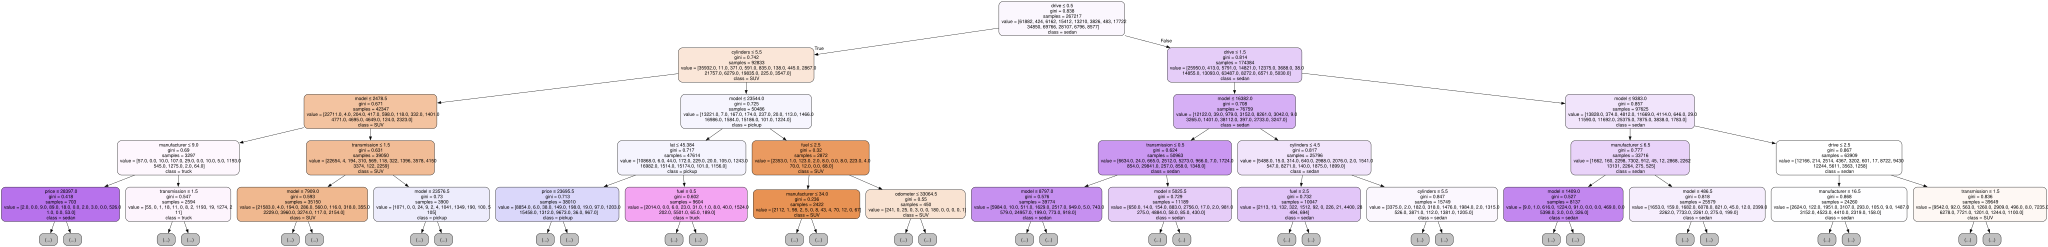

In [49]:
# Exportamos el árbol de decision (requiere tener Graphviz esté instalado)
grafico_arbol = export_graphviz(
    arbol_decision,
    out_file=None,
    feature_names=X.columns,
    class_names=label_encoders['type'].classes_,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=4
)

print(f"El árbol tiene una profundidad de: {arbol_decision.get_depth()} niveles.")

# Mostramos el árbol de decisión
graphviz.Source(grafico_arbol)

Vamos a analizar la estructura del árbol de decisión generado tras el entrenamiento del modelo:

![Árbol de decisión](media/output_arbol_decision.svg)

En la imagen, podemos comprobar que el árbol comienza con un atributo como `drive`, `odometer` o `fuel`, lo cual indica que ese atributo tiene un **alto poder de discriminación** para predecir la clase del vehículo. A medida que se desciende en el árbol, se van utilizando atributos como `cylinders`, `manufacturer` o `size`, lo cual muestra cómo el modelo **refina su decisión** con más información específica.

En cada nodo, mostramos el **atributo** utilizado para la división, el **valor del Gini** (impureza del nodo), la **cantidad de ejemplos** en ese nodo, la **distribución de clases** y la **clase mayoritaria**. En esta visualización hemos limitado la profundidad a 4 niveles para mejorar la legibilidad. Sin embargo, el modelo completo tiene más niveles y ramas, lo que indica que el árbol es más complejo y puede capturar interacciones más sutiles entre los atributos.

Una de las ventajas de este modelo es que **las decisiones pueden explicarse con reglas simples** como:

> *Si `drive = 4wd` y `odometer` < 100000 y `manufacturer = ford` → entonces probablemente sea `pickup`.*

Este tipo de reglas son muy útiles en el contexto del desguace, ya que permiten entender y validar el funcionamiento del sistema automático de clasificación de coches. 

En modelos pequeños, una profundidad de 44 niveles sería una clara señal de sobreajuste. Sin embargo, en nuestro caso estamos trabajando con un conjunto de entrenamiento de aproximadamente 300.000 vehículos, lo que justifica que el modelo necesite más niveles para capturar patrones sutiles y dividir adecuadamente una gran cantidad de clases y combinaciones posibles.

**Referencias:**
* [DataCamp: Decision Tree Classification in Python Tutorial.](https://www.datacamp.com/tutorial/decision-tree-classification-python)
* [Geeks for Geeks: Building and Implementing Decision Tree Classifiers with Scikit-Learn: A Comprehensive Guide.](https://www.geeksforgeeks.org/building-and-implementing-decision-tree-classifiers-with-scikit-learn-a-comprehensive-guide/)
* [StackAbuse: Decision Trees in Python with Scikit-Learn.](https://stackabuse.com/decision-trees-in-python-with-scikit-learn/)
* [Aprende Machine Learning: Arbol de Decisión en Python: Clasificación y predicción.](https://www.aprendemachinelearning.com/arbol-de-decision-en-python-clasificacion-y-prediccion/)
* [ichi.pro:  Visualización de árboles de decisión con Python (Scikit-learn, Graphviz, Matplotlib).](https://ichi.pro/es/visualizacion-de-arboles-de-decision-con-python-scikit-learn-graphviz-matplotlib-31132954028252)